# 05 · Estadística descriptiva
### Proyecto Olist · Python → MySQL → Tableau

---
# Librerías

In [ ]:
import os
from dotenv import load_dotenv
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

output_path = "output"

---
# 1️⃣ Export desde MySQL

Cruzamos las 5 tablas y guardamos el CSV que alimentará a la herramienta de visualización.
Hacerlo desde Python evita problemas con Workbench ( a veces, exporta menos filas, python es más seguro)

In [ ]:
# load_dotenv() lo lee y lo deja disponible con os.getenv()
load_dotenv()

# try/except → si algo falla (contraseña incorrecta, MySQL apagado...)
# imprime el error en lugar de romper el notebook sin explicación
try:
    cnx = mysql.connector.connect(
    host     = os.getenv('MYSQL_HOST'),
    user     = os.getenv('MYSQL_USER'),
    password = os.getenv('MYSQL_PASSWORD'),
    database = "olist",                      
    auth_plugin='mysql_native_password',
)
    print('✅ Conexión exitosa')

except mysql.connector.Error as e:
    print('❌ Error al conectar:', e)

✅ Conexión exitosa


In [ ]:
# Para enviar consultas SQL desde Python necesitamos dos cosas:
# cnx → la conexión con MySQL 
# cursor → el objeto que envía y ejecuta las consultas dentro de esa conexión 
# Sin cursor no podemos ejecutar nada, aunque la conexión esté abierta
cursor = cnx.cursor()

print('✅ Cursor creado correctamente')

✅ Cursor creado correctamente


In [ ]:
# hacemos una macroconsulta para cruzar las 5 tablas y exportar el CSV que alimentará Tableau
query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    c.customer_state,
    p.product_category_name,
    oi.price,
    r.review_score
FROM orders o
JOIN customers   c  ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id    = oi.order_id
JOIN products    p  ON oi.product_id = p.product_id
LEFT JOIN reviews r ON o.order_id    = r.order_id
ORDER BY o.order_purchase_timestamp
"""


In [ ]:
cursor.execute(query)
columnas = [col[0] for col in cursor.description]
df = pd.DataFrame(cursor.fetchall(), columns=columnas)
df.to_csv(os.path.join(output_path, "olist_tableau.csv"), index=False)
print(f"💾 olist_tableau.csv guardado: {len(df):,} filas")

💾 olist_tableau.csv guardado: 100,196 filas


---
# 2️⃣ PRICE — Gasto típico por pedido

Variable continua → `describe()` + histograma + boxplot

El CSV cruza `orders` con `order_items` — un pedido puede tener varios productos.
Agrupamos por `order_id` antes de calcular.

In [ ]:
## 1️⃣ MÉTRICAS

# Convertir price a numérico por si viene como string del CSV (a veces, hay errores al leerlo pandas)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Agrupar por pedido — un pedido puede tener varios productos
gasto_por_pedido = df.groupby('order_id')['price'].sum().reset_index(name='price')

print(gasto_por_pedido['price'].describe().round(2))
print(f"\nMedia:   {gasto_por_pedido['price'].mean():.2f} BRL")
print(f"Mediana: {gasto_por_pedido['price'].median():.2f} BRL")

count    96478.00
mean       128.52
std        192.46
min          0.85
25%         43.56
50%         79.90
75%        144.00
max       6735.00
Name: price, dtype: float64

Media:   128.52 BRL
Mediana: 79.90 BRL


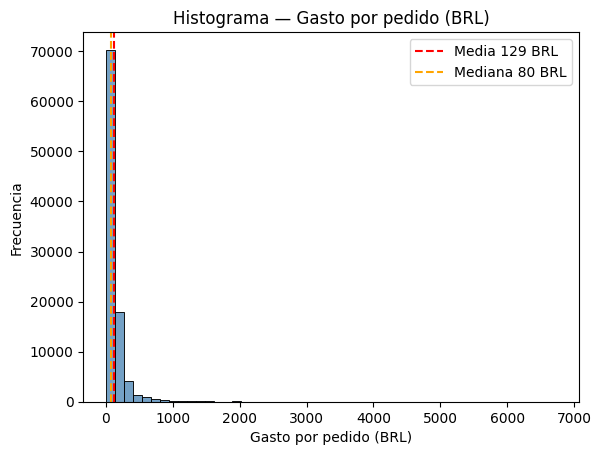

In [ ]:
## 2️⃣ HISTOGRAMA

sns.histplot(data=gasto_por_pedido, x='price', bins=50, color='steelblue')
plt.axvline(gasto_por_pedido['price'].mean(),
            color='red', linestyle='--',
            label=f"Media {gasto_por_pedido['price'].mean():.0f} BRL")
plt.axvline(gasto_por_pedido['price'].median(),
            color='orange', linestyle='--',
            label=f"Mediana {gasto_por_pedido['price'].median():.0f} BRL")
plt.title('Histograma — Gasto por pedido (BRL)')
plt.xlabel('Gasto por pedido (BRL)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

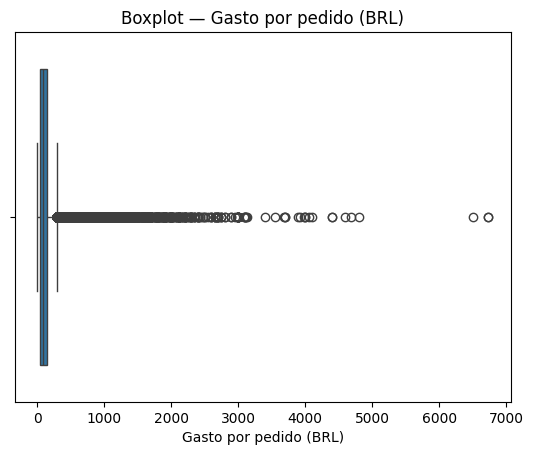

In [ ]:
## 3️⃣ BOXPLOT

sns.boxplot(data=gasto_por_pedido, x='price')
plt.title('Boxplot — Gasto por pedido (BRL)')
plt.xlabel('Gasto por pedido (BRL)')
plt.show()

In [ ]:
## 4️⃣ CONCLUSIÓN

media   = gasto_por_pedido['price'].mean()
mediana = gasto_por_pedido['price'].median()

print(f"Media {media:.0f} BRL > Mediana {mediana:.0f} BRL → distribución sesgada a la derecha.")
print(f"Hay pedidos con importes muy altos que distorsionan la media.")
print(f"→ Usamos la mediana ({mediana:.0f} BRL) como gasto típico en Tableau.")

Media 129 BRL > Mediana 80 BRL → distribución sesgada a la derecha.
Hay pedidos con importes muy altos que distorsionan la media.
→ Usamos la mediana (80 BRL) como gasto típico en Tableau.


> **Conclusión:** La distribución de gasto por pedido está sesgada a la derecha. La mediana es más representativa porque no se ve afectada por los pedidos de mayor importe — por eso es la métrica que usamos en Tableau para el KPI de gasto típico.

---
# 3️⃣ REVIEW_SCORE — % satisfechos

Variable discreta ordinal → `value_counts()` + gráfico de barras

In [ ]:
## 1️⃣ MÉTRICAS

# variable discreta → no usamos describe(), usamos value_counts()
# sort_index() → fuerza el orden 1-2-3-4-5
conteo     = df['review_score'].value_counts().sort_index()
porcentaje = df['review_score'].value_counts(normalize=True).sort_index() * 100

resumen = pd.DataFrame({'total': conteo, 'porcentaje (%)': porcentaje.round(1)})
print(resumen)

satisfechos   = porcentaje[porcentaje.index >= 4].sum()
insatisfechos = porcentaje[porcentaje.index <= 2].sum()
print(f"\nSatisfechos (4-5 estrellas):   {satisfechos:.1f}%")
print(f"Insatisfechos (1-2 estrellas): {insatisfechos:.1f}%")

              total  porcentaje (%)
review_score                       
1.0           10335            10.4
2.0            3201             3.2
3.0            8307             8.3
4.0           19379            19.5
5.0           58281            58.6

Satisfechos (4-5 estrellas):   78.0%
Insatisfechos (1-2 estrellas): 13.6%


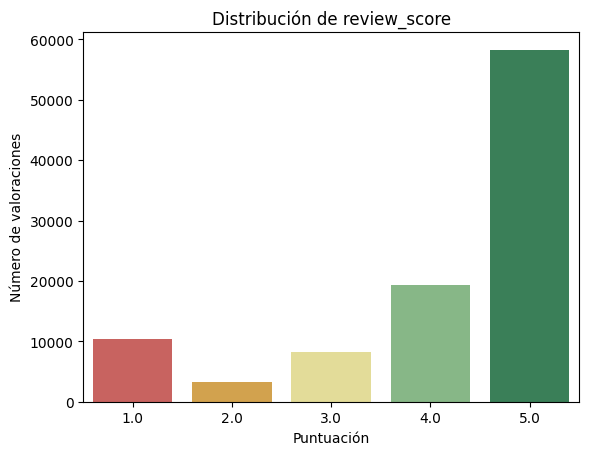

In [ ]:
## 2️⃣ DISTRIBUCIÓN

# countplot — diseñado para contar categorías
# hue + legend=False → forma correcta de aplicar colores por categoría en seaborn v0.14
palette = {1: '#d9534f', 2: '#e8a838', 3: '#f0e68c', 4: '#7fbf7f', 5: '#2e8b57'}

sns.countplot(data=df, x='review_score',
              hue='review_score', palette=palette, legend=False)
plt.title('Distribución de review_score')
plt.xlabel('Puntuación')
plt.ylabel('Número de valoraciones')
plt.show()

In [ ]:
## 3️⃣ CONCLUSIÓN

print(f"El {satisfechos:.1f}% de los clientes puntúa con 4 o 5 estrellas.")
print(f"El {insatisfechos:.1f}% puntúa con 1 o 2 estrellas.")
print(f"Los datos cuantitativos no explican ese {insatisfechos:.1f}% — la causa no está en el precio ni en la categoría.")
print(f"Para entenderlo habría que leer las reseñas escritas.")

El 78.0% de los clientes puntúa con 4 o 5 estrellas.
El 13.6% puntúa con 1 o 2 estrellas.
Los datos cuantitativos no explican ese 13.6% — la causa no está en el precio ni en la categoría.
Para entenderlo habría que leer las reseñas escritas.


> **Conclusión:** La satisfacción es alta — la mayoría puntúa con 4 o 5 estrellas. El % insatisfecho es un porcentaje aceptable en ecommerce. 